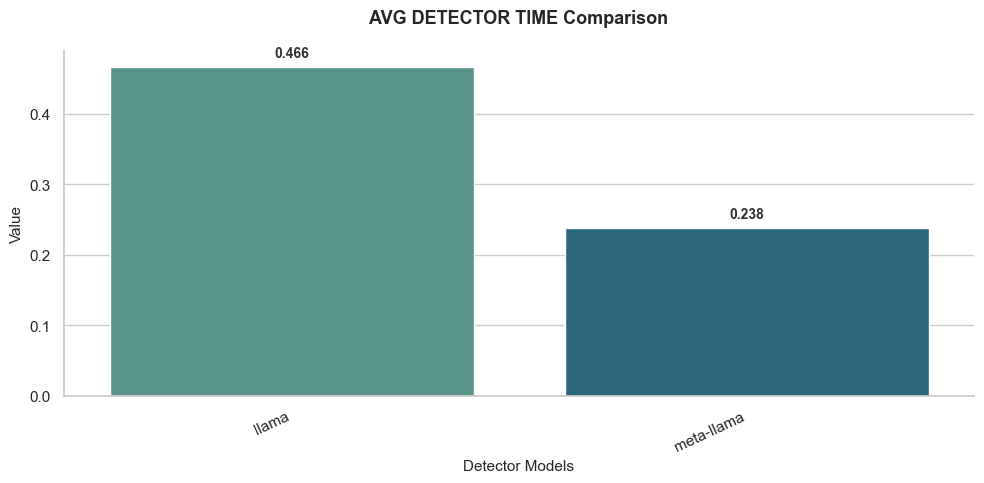

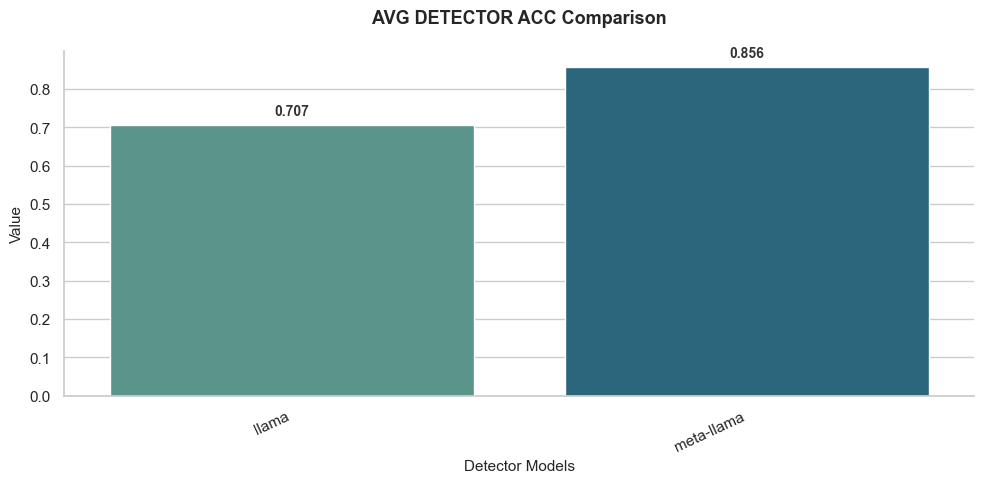

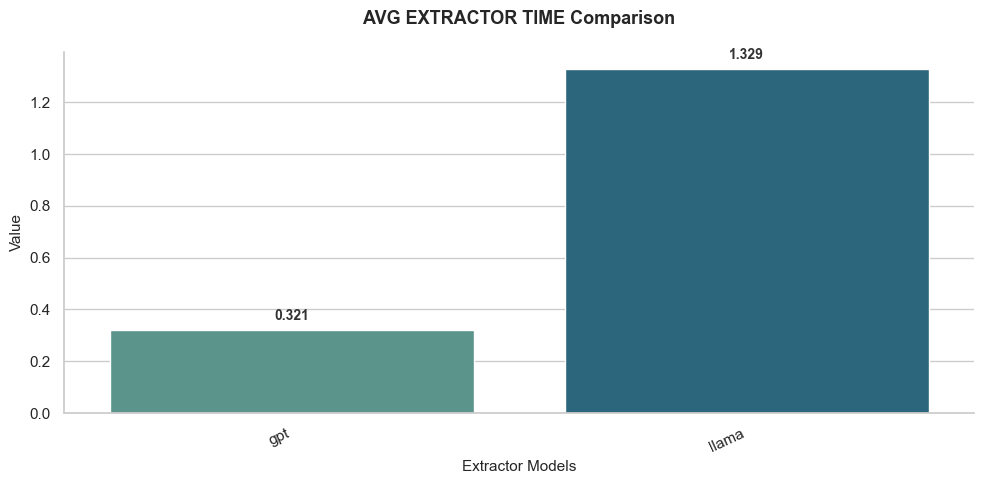

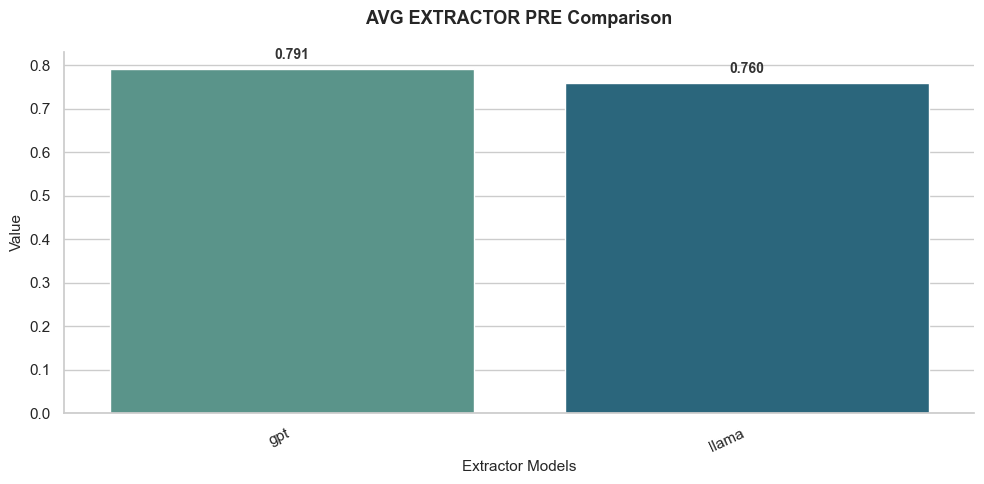

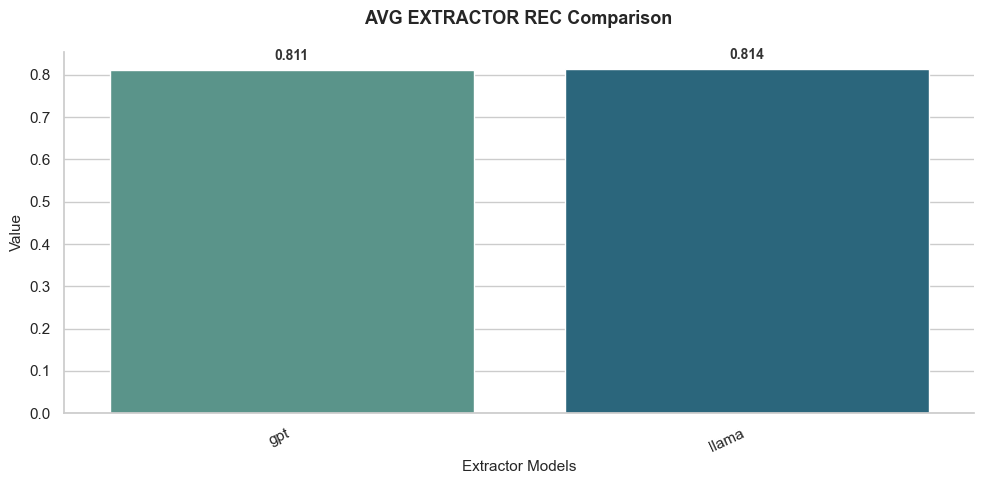

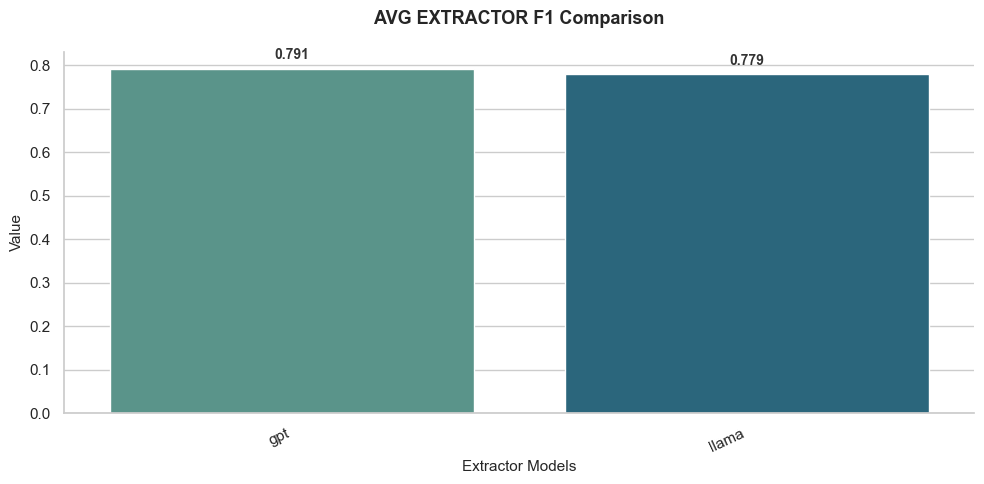

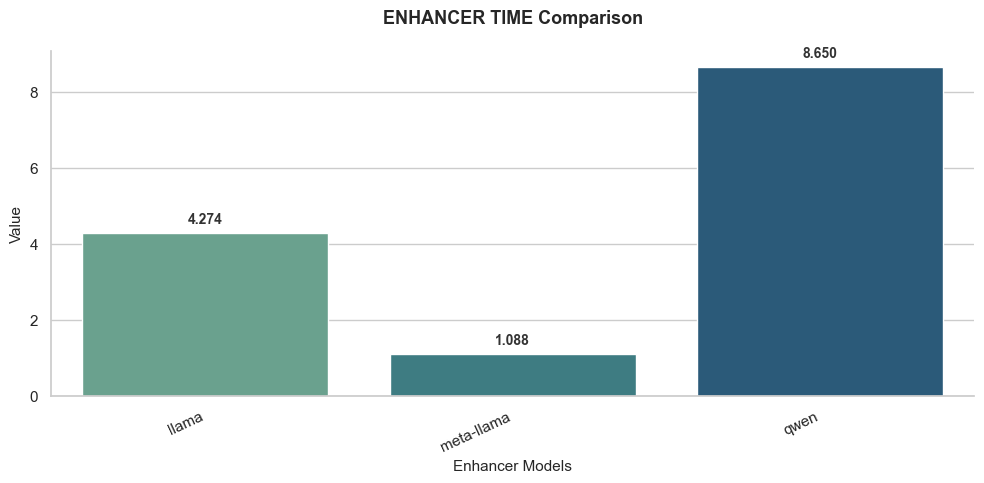

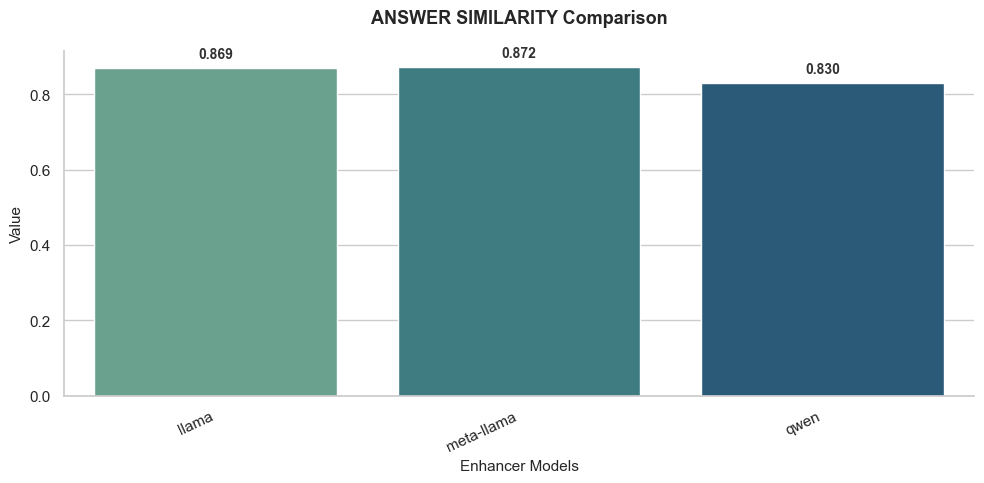

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
UNIQUE_PALETTE = "crest" 

file_path = "llm_results.csv"
df = pd.read_csv(file_path)

groups = [
    {"metrics": ["avg_detector_time", "avg_detector_acc"], "model_col": "detector"},
    {"metrics": ["avg_extractor_time", "avg_extractor_pre", "avg_extractor_rec", "avg_extractor_f1"], "model_col": "extractor"},
    {"metrics": ["enhancer_time", "answer_similarity"], "model_col": "enhancer"}
]

for group in groups:
    model_col = group["model_col"]
    
    for metric in group["metrics"]:
        plt.figure(figsize=(10, 5))
        
        filtered_df = df[df["metric"] == metric]
        grouped = filtered_df.groupby(model_col)["value"].mean().reset_index()
        
        ax = sns.barplot(
            data=grouped, 
            x=model_col, 
            y="value", 
            palette=UNIQUE_PALETTE,
            hue=model_col,
            legend=False
        )
        
        clean_title = metric.replace('_', ' ').upper()
        plt.title(f"{clean_title} Comparison", fontsize=13, fontweight='bold', pad=20)
        plt.xlabel(f"{model_col.capitalize()} Models", fontsize=11)
        plt.ylabel("Value", fontsize=11)
        
        plt.xticks(rotation=25, ha='right')
        
        sns.despine()
        
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.3f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 10), 
                        textcoords='offset points',
                        fontsize=10, fontweight='bold', color='#333')

        plt.tight_layout()
        plt.show()